# Amazon Sales Dataset Analysis
### Python Data Analysis | 50,000 Orders | 2022–2023

**Tools:** Python · Pandas · NumPy · Seaborn · Matplotlib  
**Dataset:** 50,000 Amazon sales orders across 13 columns  
**Goal:** Understand sales performance across categories, regions, payment methods and time periods to identify growth opportunities and risks.

---

---
## Phase 1: Data Loading & First Look
---

In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

df = pd.read_csv("amazon_sales_dataset.csv")

### Step 1.1 — Dataset Shape & Structure

In [2]:
print(f"Dataset Shape: {df.shape}")
print(f"\nColumn Data Types:")
print(df.dtypes)

Dataset Shape: (50000, 13)

Column Data Types:
order_id              int64
order_date              str
product_id            int64
product_category        str
price               float64
discount_percent      int64
quantity_sold         int64
customer_region         str
payment_method          str
rating              float64
review_count          int64
discounted_price    float64
total_revenue       float64
dtype: object


### Step 1.2 — First & Last Rows Preview

In [3]:
print("First 5 rows:")
df.head()

First 5 rows:


,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


In [4]:
print("Last 5 rows:")
df.tail()

Last 5 rows:


,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
49995,49996,2022-09-03,1433,Beauty,26.99,0,5,Middle East,Credit Card,2.4,386,26.99,134.95
49996,49997,2022-07-03,1428,Beauty,294.23,10,5,Asia,Credit Card,3.1,8,264.81,1324.05
49997,49998,2023-02-17,4651,Electronics,352.11,30,4,Asia,Debit Card,3.1,104,246.48,985.92
49998,49999,2022-09-30,4371,Beauty,307.54,5,1,Middle East,UPI,1.8,316,292.16,292.16
49999,50000,2023-06-29,2944,Home & Kitchen,253.44,30,1,Europe,Debit Card,2.1,464,177.41,177.41


### Step 1.3 — Descriptive Statistics

In [5]:
df.describe()

,order_id,product_id,price,discount_percent,quantity_sold,rating,review_count,discounted_price,total_revenue
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,2986.848740,252.507260,13.340700,2.999400,2.996316,249.329280,218.886566,657.331475
std,14433.901067,1156.374535,143.025544,9.850694,1.415401,1.154295,144.251981,127.317681,526.223968
min,1.000000,1000.000000,5.010000,0.000000,1.000000,1.000000,0.000000,3.530000,3.840000
25%,12500.750000,1983.000000,127.840000,5.000000,2.000000,2.000000,125.000000,109.680000,240.320000
50%,25000.500000,2983.000000,252.970000,10.000000,3.000000,3.000000,250.000000,215.805000,505.410000
75%,37500.250000,3989.000000,376.335000,20.000000,4.000000,4.000000,374.000000,322.702500,968.970000
max,50000.000000,4999.000000,499.990000,30.000000,5.000000,5.000000,499.000000,499.910000,2499.550000


### Phase 1 Key Observations

| Finding | Status |
|---------|--------|
| Dataset size | 50,000 rows × 13 columns ✅ |
| Missing values | None detected (count = 50,000 for all columns) ✅ |
| `order_date` dtype | String (object) — needs conversion to datetime 🚩 |
| `rating` range | 1.0 to 5.0 — valid ✅ |
| `total_revenue` | Mean (657) > Median (505) — right skewed ⚠️ |
| `discount_percent` | Contains 0 values — needs investigation 🚩 |

> **Analyst Note:** Revenue is right-skewed — a small number of large orders are pulling the mean upward. The median (505) is a more reliable indicator of a typical order value.

---
##  Phase 2: Data Cleaning
---

### Step 2.1 — Duplicate Check

In [6]:
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Unique order_ids: {df['order_id'].nunique()}")

Duplicate rows: 0
Unique order_ids: 50000


> **Result:** Zero duplicate rows. All 50,000 order IDs are unique — data integrity confirmed.

### Step 2.2 — Fix `order_date` Data Type (String → Datetime)

In [7]:
df['order_date'] = pd.to_datetime(df['order_date'])

print(f"order_date dtype after conversion: {df['order_date'].dtype}")

order_date dtype after conversion: datetime64[us]


> **Result:** `order_date` successfully converted to `datetime64`. This enables time-based analysis (monthly trends, year-over-year comparison) which would not be possible with string format.

### Step 2.3 — Extract Date Features

In [8]:
df['order_Year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['order_day_of_week'] = df['order_date'].dt.dayofweek

print("New date columns created:")
df[['order_Year', 'order_month', 'order_day_of_week']].head()

New date columns created:


,order_Year,order_month,order_day_of_week
0,2022,4,2
1,2023,3,6
2,2022,9,2
3,2022,4,6
4,2022,3,6


> **Result:** Extracted `order_Year`, `order_month`, and `order_day_of_week` — enabling seasonal and time-trend analysis in Phase 3.

### Step 2.4 — Validate `discounted_price` Column

In [9]:
# Recalculate discounted price using formula
df['calculated_price'] = (df['price'] - (df['price'] * df['discount_percent'] / 100)).round(2)

# Check mismatches
mismatches = (df['calculated_price'] != df['discounted_price']).sum()
print(f"Price mismatches found: {mismatches}")

# Check the size of differences
df['price_difference'] = df['calculated_price'] - df['discounted_price']
print(f"\nMax difference: {df['price_difference'].max()}")
print(f"Min difference: {df['price_difference'].min()}")

# Drop validation columns
df.drop(columns=['calculated_price', 'price_difference'], inplace=True)
print("\nValidation columns removed. Dataset back to clean state.")

Price mismatches found: 328

Max difference: 0.010000000000047748
Min difference: -0.010000000000019327

Validation columns removed. Dataset back to clean state.


> **Result:** 328 minor mismatches found, but the maximum difference is only 0.01 (1 cent). This is a floating-point rounding issue, not a data entry error. `discounted_price` is mathematically consistent — no data integrity issue.

### Step 2.5 — Outlier Detection (IQR Method)

In [10]:
# Price outliers
price_Q1 = df['price'].quantile(0.25)
price_Q3 = df['price'].quantile(0.75)
price_IQR = price_Q3 - price_Q1
price_lower = price_Q1 - (1.5 * price_IQR)
price_upper = price_Q3 + (1.5 * price_IQR)
price_outliers = df[(df['price'] < price_lower) | (df['price'] > price_upper)].shape[0]

# Revenue outliers
Total_Rev_Q1 = df['total_revenue'].quantile(0.25)
Total_Rev_Q3 = df['total_revenue'].quantile(0.75)
Total_Rev_IQR = Total_Rev_Q3 - Total_Rev_Q1
Total_Rev_lower = Total_Rev_Q1 - (1.5 * Total_Rev_IQR)
Total_Rev_upper = Total_Rev_Q3 + (1.5 * Total_Rev_IQR)
revenue_outliers_count = df[(df['total_revenue'] < Total_Rev_lower) | (df['total_revenue'] > Total_Rev_upper)].shape[0]

# Quantity outliers
quantity_Q1 = df['quantity_sold'].quantile(0.25)
quantity_Q3 = df['quantity_sold'].quantile(0.75)
quantity_IQR = quantity_Q3 - quantity_Q1
quantity_lower = quantity_Q1 - (1.5 * quantity_IQR)
quantity_upper = quantity_Q3 + (1.5 * quantity_IQR)
quantity_outliers = df[(df['quantity_sold'] < quantity_lower) | (df['quantity_sold'] > quantity_upper)].shape[0]

print(f"Price outliers:    {price_outliers}")
print(f"Revenue outliers:  {revenue_outliers_count}")
print(f"Quantity outliers: {quantity_outliers}")

Price outliers:    0
Revenue outliers:  752
Quantity outliers: 0


In [11]:
# Investigate the 752 revenue outliers
revenue_outliers = df[(df['total_revenue'] < Total_Rev_lower) | (df['total_revenue'] > Total_Rev_upper)]

print("Revenue outlier summary:")
print(f"  Count: {len(revenue_outliers)}")
print(f"  Revenue range: {revenue_outliers['total_revenue'].min():.2f} to {revenue_outliers['total_revenue'].max():.2f}")
print(f"  Quantity sold (all): {revenue_outliers['quantity_sold'].unique()}")

Revenue outlier summary:
  Count: 752
  Revenue range: 2061.95 to 2499.55
  Quantity sold (all): [5]


> **Result:** The 752 revenue outliers all have `quantity_sold = 5` (maximum possible). These are **not data errors** — they represent legitimate high-volume orders. **Decision: Keep these rows.**

** Data Cleaning Summary:**

| Check | Finding | Action |
|-------|---------|--------|
| Duplicates | 0 found | None needed |
| order_date type | Was string | Converted to datetime |
| Date features | Missing | Extracted year, month, day_of_week |
| discounted_price | 328 rounding diffs (max 0.01) | No action — rounding only |
| Price outliers | 0 found | None needed |
| Revenue outliers | 752 found (quantity=5) | Kept — legitimate orders |
| Quantity outliers | 0 found | None needed |

---
## Phase 3: Exploratory Data Analysis (EDA)
---

### Step 3.1 — Category Analysis: Revenue & Rating

In [12]:
total_revenue_by_category = df.groupby("product_category")["total_revenue"].sum().sort_values(ascending=False)
print("Total Revenue by Category:")
print(total_revenue_by_category)

Total Revenue by Category:
product_category
Beauty            5550624.97
Books             5484863.03
Fashion           5480123.34
Home & Kitchen    5473132.55
Electronics       5470594.03
Sports            5407235.82
Name: total_revenue, dtype: float64


In [13]:
highest_average_rating_category = df.groupby("product_category")["rating"].mean().sort_values(ascending=False).round(2)
print("Average Rating by Category:")
print(highest_average_rating_category)

Average Rating by Category:
product_category
Books             3.02
Sports            3.00
Home & Kitchen    3.00
Electronics       2.99
Fashion           2.99
Beauty            2.99
Name: rating, dtype: float64


> ** Key Finding — Category Analysis:**  
> Beauty leads revenue at **5.6M** but has the **lowest** customer rating (2.99), while Books has the **highest** rating (3.02) but ranks **last** in revenue (5.4M) — a clear satisfaction-revenue disconnect.  
> **Implication:** Amazon should prioritize improving Beauty's customer experience while investing in Books marketing to capitalize on its strong satisfaction scores.

### Step 3.2 — Regional Analysis: Orders & Revenue

In [14]:
print("Orders by Region:")
print(df["customer_region"].value_counts().sort_values(ascending=False))

Orders by Region:
customer_region
Asia             12526
North America    12517
Middle East      12505
Europe           12452
Name: count, dtype: int64


In [15]:
print("Total Revenue by Region:")
print(df.groupby("customer_region")["total_revenue"].sum().sort_values(ascending=False))

Total Revenue by Region:
customer_region
Middle East      8301844.50
North America    8277217.84
Asia             8175199.83
Europe           8112311.57
Name: total_revenue, dtype: float64


In [16]:
print("Average Order Value by Region:")
print(df.groupby("customer_region")["total_revenue"].mean().sort_values(ascending=False).round(2))

Average Order Value by Region:
customer_region
Middle East      663.88
North America    661.28
Asia             652.66
Europe           651.49
Name: total_revenue, dtype: float64


> **Key Finding — Regional Analysis:**  
> Asia leads in order count (12,526) but Middle East generates the most revenue (8.30M) due to a higher average order value (663.88 vs 652.66) — proving quality beats quantity.  
> Revenue gap across all 4 regions is only 0.19M (2.3%) — highly even distribution.

### Step 3.3 — Payment Method Analysis

In [17]:
print("Orders by Payment Method:")
print(df["payment_method"].value_counts())

Orders by Payment Method:
payment_method
Wallet              10106
UPI                 10078
Debit Card           9981
Cash on Delivery     9927
Credit Card          9908
Name: count, dtype: int64


In [18]:
print("Revenue by Payment Method:")
print(df.groupby("payment_method")["total_revenue"].sum().sort_values(ascending=False))

Revenue by Payment Method:
payment_method
Wallet              6678638.47
UPI                 6579441.44
Cash on Delivery    6546386.94
Credit Card         6540087.16
Debit Card          6522019.73
Name: total_revenue, dtype: float64


In [19]:
print("Average Order Value by Payment Method:")
print(df.groupby("payment_method")["total_revenue"].mean().sort_values(ascending=False).round(2))

Average Order Value by Payment Method:
payment_method
Wallet              660.86
Credit Card         660.08
Cash on Delivery    659.45
Debit Card          653.44
UPI                 652.85
Name: total_revenue, dtype: float64


> **Key Finding — Payment Analysis:**  
> Wallet dominates both order count (10,106) and revenue (6.68M). However, all 5 payment methods generate within 0.16M (2.4%) of each other — the platform is effectively **payment-method agnostic**.

### Step 3.4 — Time Analysis: Year & Monthly Trends

In [20]:
year_counts = df["order_Year"].value_counts()
print("Orders by Year:")
print(year_counts)

new = year_counts[2023]
old = year_counts[2022]
difference_between_years_sales = ((new - old) / old) * 100
print(f"\n2022 vs 2023 order growth: {round(difference_between_years_sales, 2)}%")

Orders by Year:
order_Year
2023    25074
2022    24926
Name: count, dtype: int64

2022 vs 2023 order growth: 0.59%


In [21]:
monthly_revenue = df.groupby("order_month")["total_revenue"].sum().reset_index()
print("Revenue by Month:")
print(monthly_revenue)

Revenue by Month:
    order_month  total_revenue
0             1     2883926.88
1             2     2505094.80
2             3     2759003.83
3             4     2678973.77
4             5     2806178.34
5             6     2746947.62
6             7     2788265.84
7             8     2845629.94
8             9     2744974.92
9            10     2760754.34
10           11     2625428.52
11           12     2721394.94


> **Key Finding — Time Analysis:**  
> Only **0.59% order growth** between 2022 and 2023 — essentially flat.  
> Monthly revenue ranges from 2.5M (Feb) to 2.9M (Jan) — only a **14% gap**, suggesting **no strong seasonal dependency** in this dataset.

### Step 3.5 — Discount Impact Analysis

In [22]:
avg_quantity_sold_per_discount = df.groupby("discount_percent")["quantity_sold"].mean().round(2).reset_index()

max_qty = avg_quantity_sold_per_discount["quantity_sold"].max()
min_qty = avg_quantity_sold_per_discount["quantity_sold"].min()
pct_diff = ((max_qty - min_qty) / min_qty) * 100

print(f"Max avg quantity (across discount levels): {max_qty}")
print(f"Min avg quantity (across discount levels): {min_qty}")
print(f"% difference: {round(pct_diff, 2)}%")

Max avg quantity (across discount levels): 3.03
Min avg quantity (across discount levels): 2.98
% difference: 1.68%


> **Key Finding — Discount Analysis:**  
> Average quantity sold ranges from **2.98 to 3.03** across all discount levels (0%–30%) — a difference of just **1.67%**.  
> Discounts have **virtually no impact** on purchase quantity. Amazon may be losing margin unnecessarily.

---
## Phase 4: Visualizations
---

**Formatter function used across all charts:**

In [23]:
def millions(x, pos):
    return f'{x/1e6:.1f}M'

### Chart 1 — Total Revenue by Category

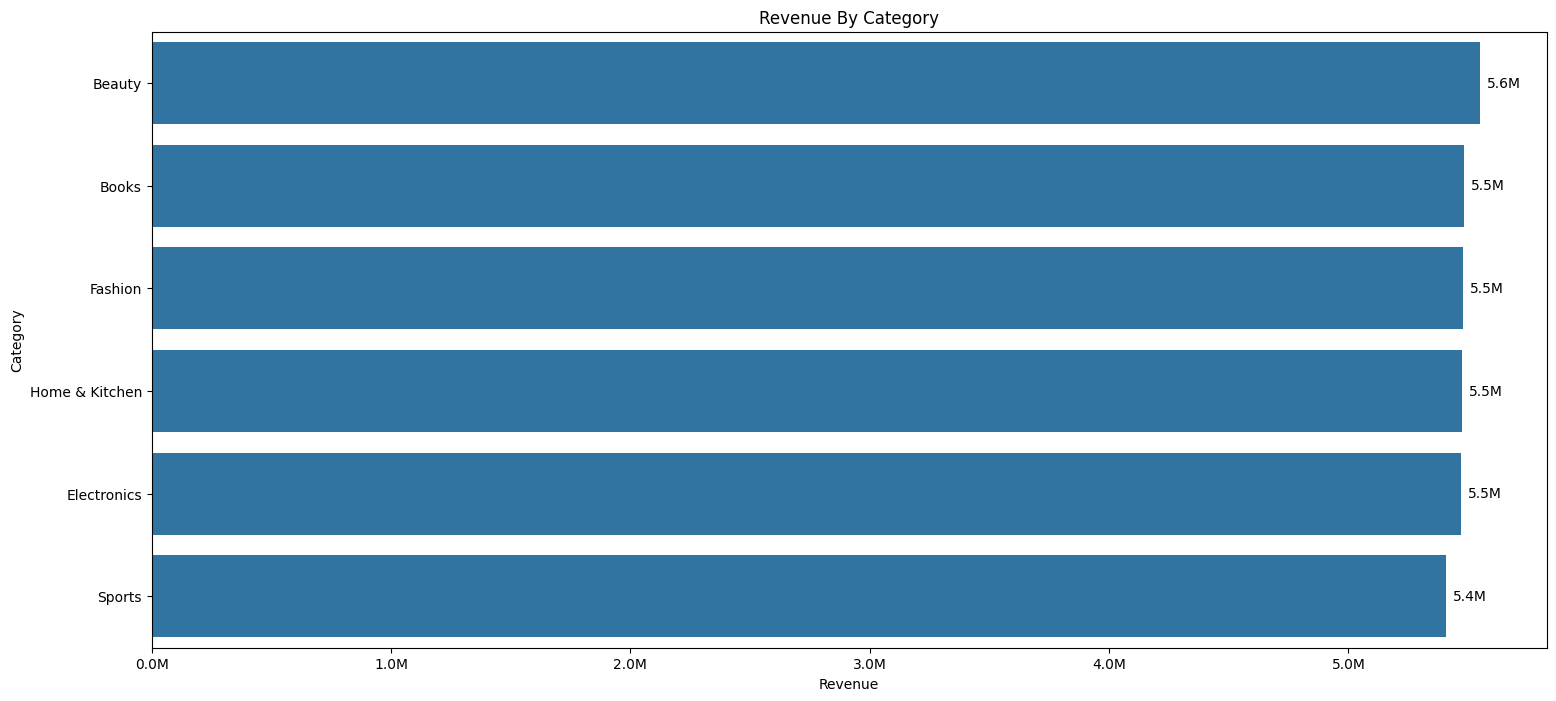

In [24]:
total_revenue_by_category = df.groupby("product_category")["total_revenue"].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(18, 8))
sns.barplot(data=total_revenue_by_category, x='total_revenue', y='product_category')
plt.bar_label(plt.gca().containers[0], labels=[f'{x/1e6:.1f}M' for x in total_revenue_by_category['total_revenue']], padding=5)
plt.title('Revenue By Category')
plt.xlabel('Revenue')
plt.ylabel('Category')
plt.gca().xaxis.set_major_formatter(FuncFormatter(millions))
plt.show()

> **Chart 1 Insight — Revenue by Category:**  
> Revenue ranges from **5.4M (Sports)** to **5.6M (Beauty)** — gap of only **0.2M (3.5%)**.  
> Revenue is remarkably evenly distributed — no single category dominates.  
> **Recommendation:** Since no category significantly outperforms others, Amazon should focus on improving customer satisfaction in Beauty (highest revenue, lowest rating) and capitalize on Books' strong ratings.

### Chart 2 — Total Revenue by Region

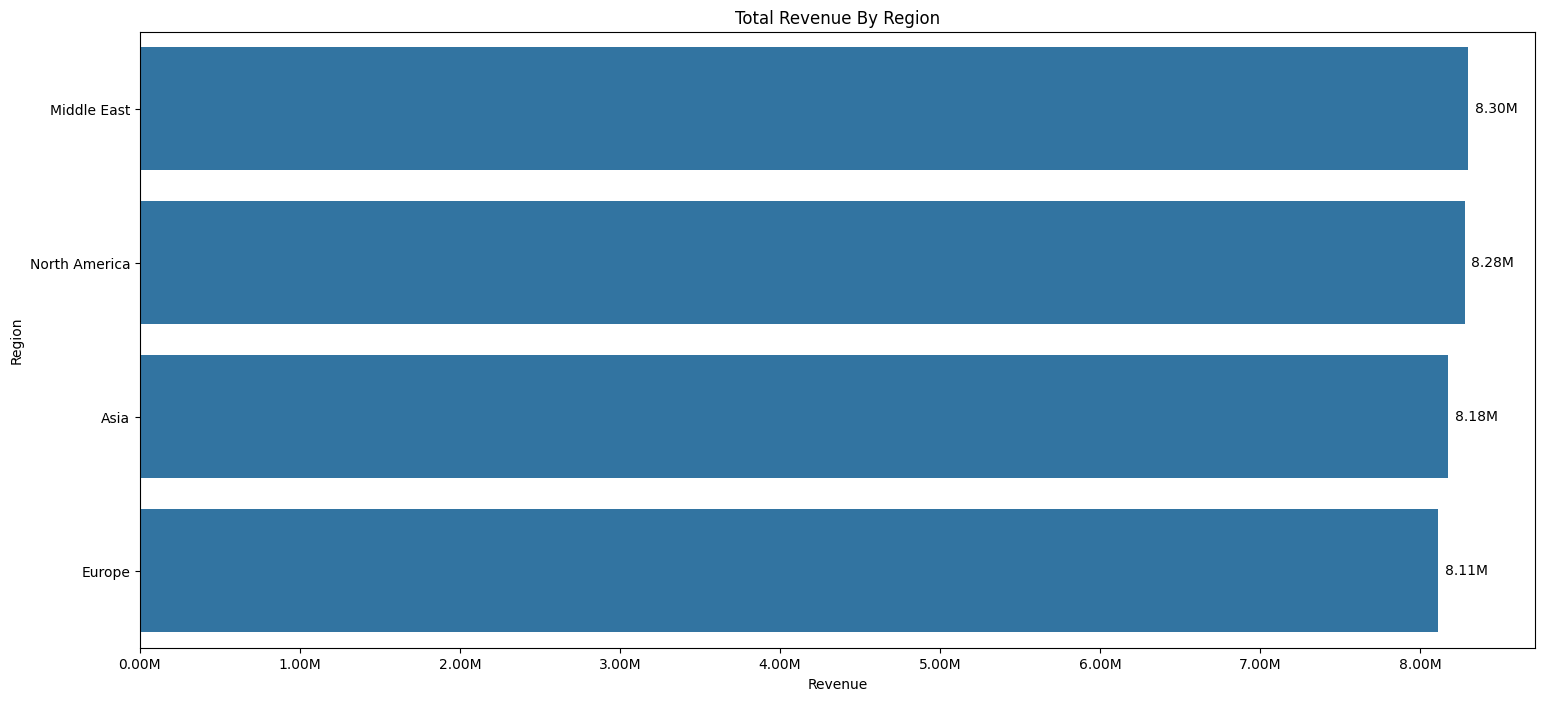

Revenue gap across regions: 0.19M


In [25]:
total_revenue_by_region = df.groupby('customer_region')['total_revenue'].sum().sort_values(ascending=False).reset_index()

def millions2(x, pos):
    return f'{x/1e6:.2f}M'

plt.figure(figsize=(18, 8))
sns.barplot(data=total_revenue_by_region, x='total_revenue', y='customer_region')
plt.bar_label(plt.gca().containers[0], labels=[f'{x/1e6:.2f}M' for x in total_revenue_by_region['total_revenue']], padding=5)
plt.title("Total Revenue By Region")
plt.ylabel("Region")
plt.xlabel("Revenue")
plt.gca().xaxis.set_major_formatter(FuncFormatter(millions2))
plt.show()

rev_region_gap = total_revenue_by_region['total_revenue'].max() - total_revenue_by_region['total_revenue'].min()
print(f'Revenue gap across regions: {rev_region_gap/1e6:.2f}M')

> **Chart 2 Insight — Revenue by Region:**  
> Revenue ranges from **8.11M (Europe)** to **8.30M (Middle East)** — gap of only **0.19M (2.3%)**.  
> Despite Asia having the most orders (12,526), Middle East leads in revenue due to higher average order value (663.88 vs 652.66) — **quality beats quantity**.  
> **Recommendation:** Target Europe with premium product promotions to increase average order value from 651.49 closer to Middle East's 663.88.

### Chart 3 — Total Revenue by Payment Method

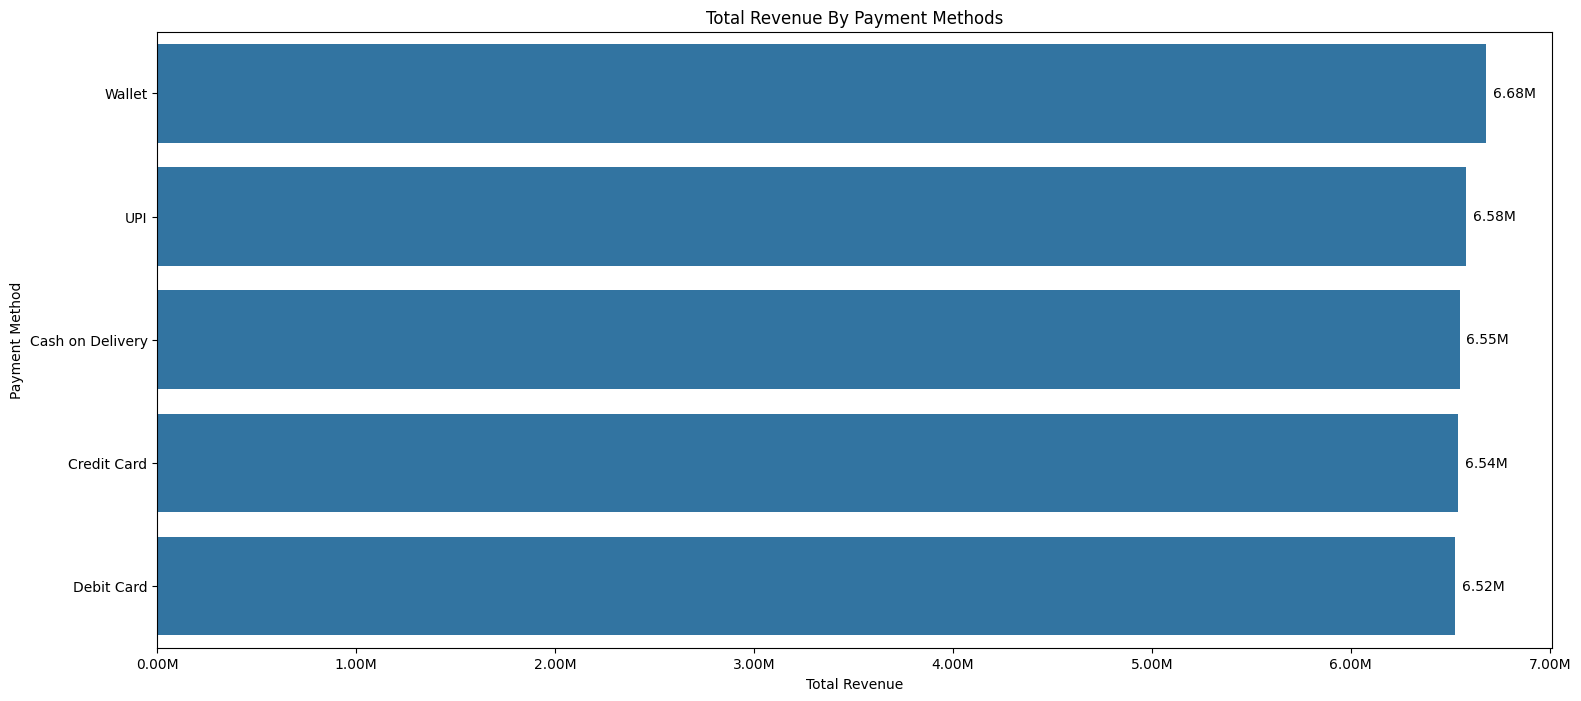

Revenue gap across payment methods: 0.16M


In [26]:
total_payment_method_by_revenue = df.groupby('payment_method')['total_revenue'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(18, 8))
sns.barplot(data=total_payment_method_by_revenue, x='total_revenue', y='payment_method')
plt.bar_label(plt.gca().containers[0], labels=[f'{x/1e6:.2f}M' for x in total_payment_method_by_revenue["total_revenue"]], padding=5)
plt.title("Total Revenue By Payment Methods")
plt.xlabel("Total Revenue")
plt.ylabel("Payment Method")
plt.gca().xaxis.set_major_formatter(FuncFormatter(millions2))
plt.show()

rev_payment_gap = total_payment_method_by_revenue['total_revenue'].max() - total_payment_method_by_revenue['total_revenue'].min()
print(f'Revenue gap across payment methods: {rev_payment_gap/1e6:.2f}M')

> **Chart 3 Insight — Revenue by Payment Method:**  
> Revenue ranges from **6.52M (Debit Card)** to **6.68M (Wallet)** — gap of only **0.16M (2.4%)**.  
> Wallet dominates both order count (10,106) and revenue, suggesting customers prefer quick digital payments.  
> **Recommendation:** Promote Wallet and UPI in emerging markets like Asia and Middle East to reduce Cash on Delivery dependency, which increases operational costs and return rates.

### Chart 4 — Monthly Revenue Trend

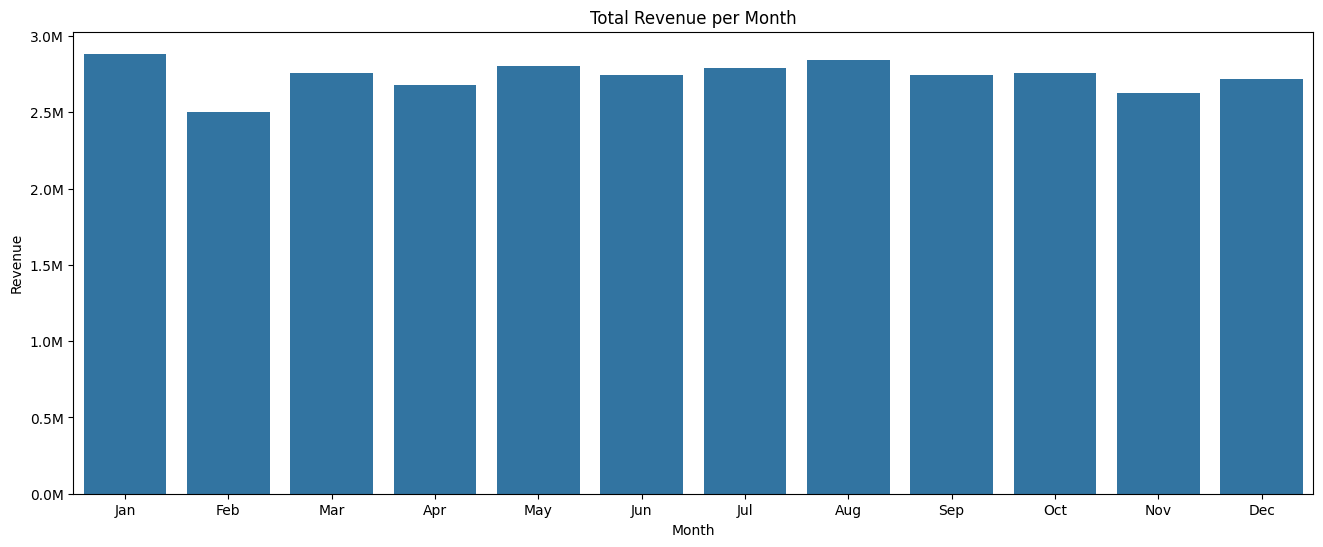

In [27]:
plt.figure(figsize=(16, 6))
sns.barplot(data=monthly_revenue, x='order_month', y='total_revenue')
plt.title('Total Revenue per Month')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
plt.xticks(ticks=range(0, 12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

> **Chart 4 Insight — Monthly Revenue:**  
> Revenue is remarkably stable year-round (2.5M–2.9M range, 14% gap). January peaks and February dips, but there is no strong seasonal dependency — suggesting **consistent year-round demand** in this dataset.

### Chart 5 — Discount Impact on Quantity Sold

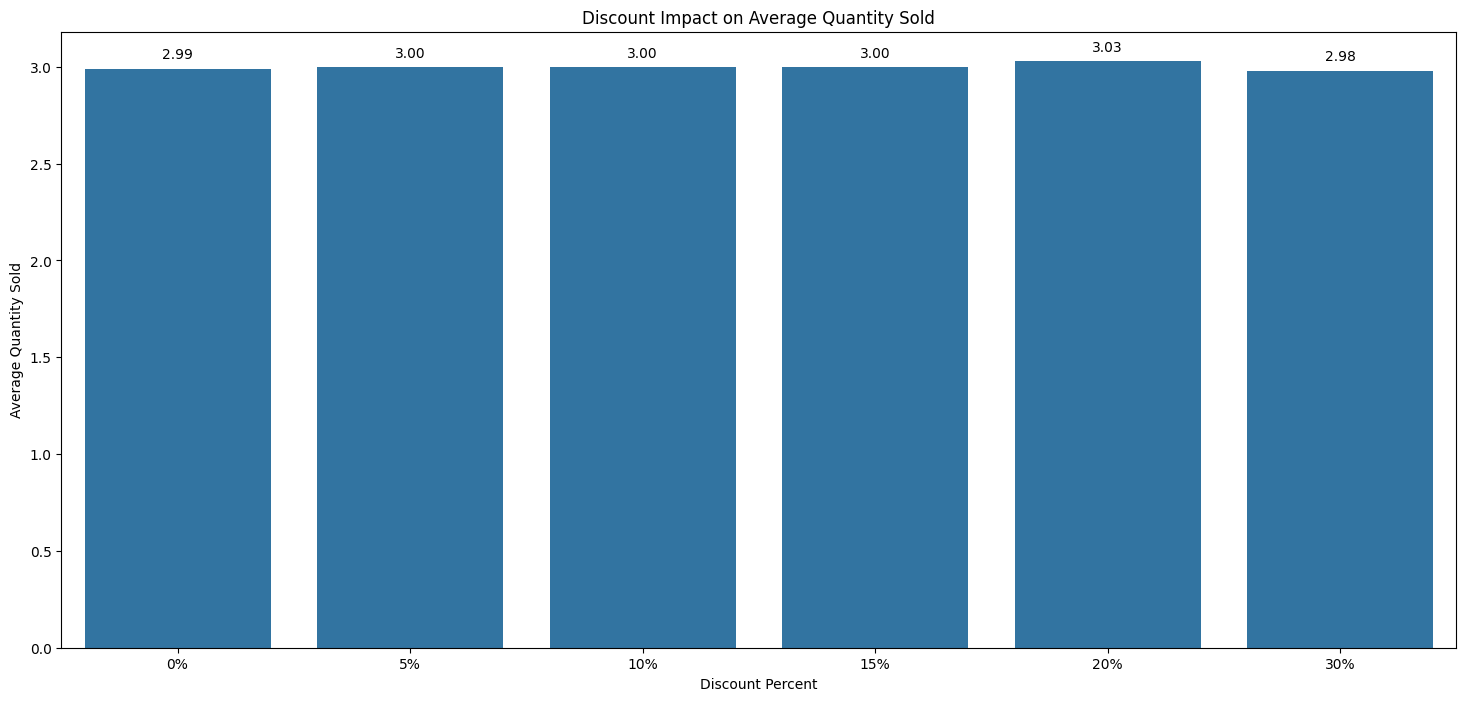

In [28]:
plt.figure(figsize=(18, 8))
sns.barplot(data=avg_quantity_sold_per_discount, x="discount_percent", y="quantity_sold")
plt.bar_label(plt.gca().containers[0], labels=[f'{y:.2f}' for y in avg_quantity_sold_per_discount['quantity_sold']], padding=5)
plt.title("Discount Impact on Average Quantity Sold")
plt.xlabel("Discount Percent")
plt.ylabel("Average Quantity Sold")
plt.xticks(ticks=range(0, 6), labels=('0%', '5%', '10%', '15%', '20%', '30%'))
plt.show()

> **Chart 5 Insight — Discount Impact:**  
> Average quantity sold is virtually identical across all discount levels (2.98–3.03, only 1.67% variance).  
> Discounts have **no measurable impact** on purchase behaviour — Amazon is reducing margins with no return in sales volume.  
> **Recommendation:** Conduct A/B testing to remove discounts from low-sensitivity categories like Books and Electronics to protect margins.

### Chart 6 — Customer Rating Distribution

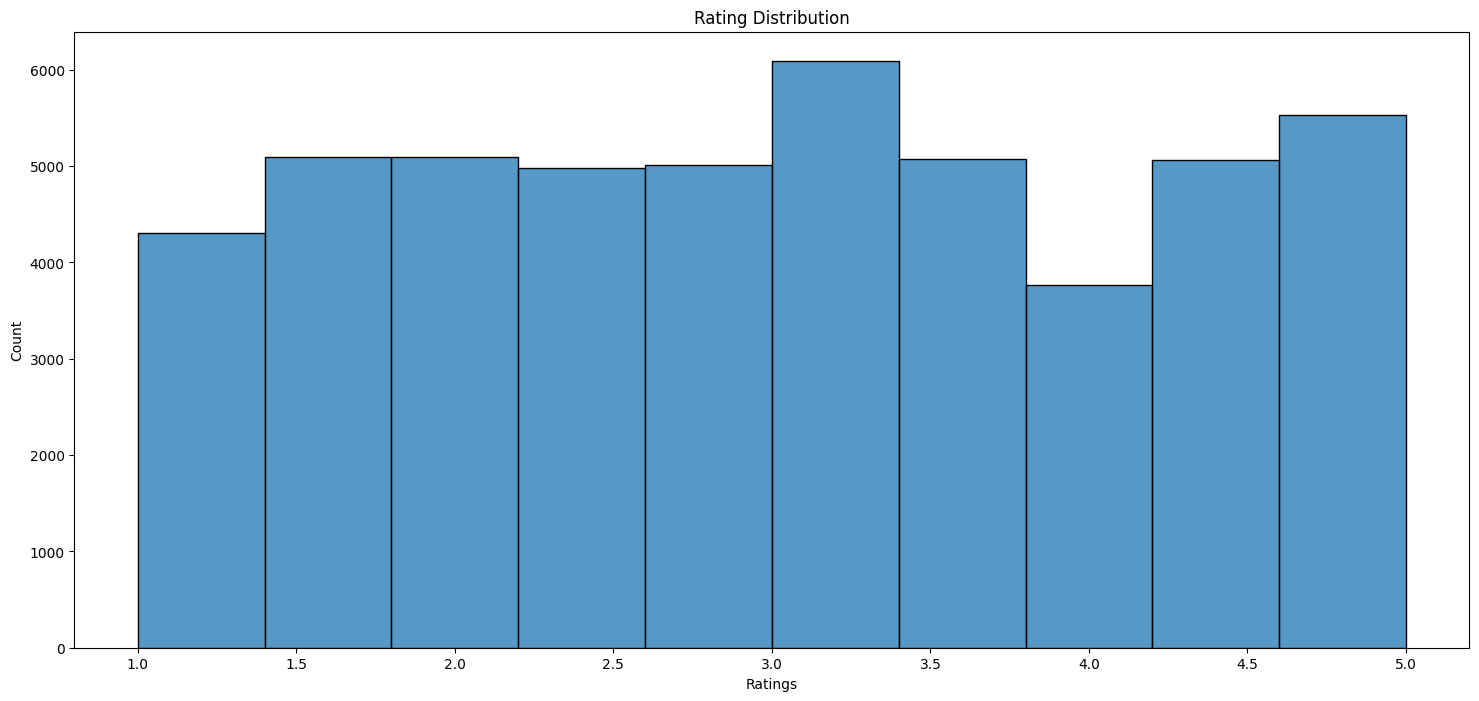

In [29]:
plt.figure(figsize=(18, 8))
sns.histplot(data=df, x='rating', bins=10)
plt.title("Rating Distribution")
plt.xlabel("Ratings")
plt.ylabel("Count")
plt.show()

> **Chart 6 Insight — Rating Distribution:**  
> Ratings are uniformly distributed between 1.0 and 5.0, with each value appearing approximately 1,200–1,330 times.  
> 
> **Important Caveat:** This uniform distribution is highly unusual for real e-commerce data. In genuine Amazon data, ratings typically follow a J-curve or U-curve where customers predominantly rate either very high (5★) or very low (1★).  
> This strongly suggests the dataset is **synthetically generated** — an important limitation when drawing business conclusions.

---
## Phase 5: Executive Business Summary
---

## Amazon Sales Analysis — Executive Summary

**Dataset:** 50,000 orders | 13 columns | 2022–2023  
**Goal:** Understand sales performance across categories, regions, payment methods and time periods to identify growth opportunities and business risks.

---

##  Key Findings

1. **Category** → Beauty leads revenue at 5.6M but has the **lowest** customer rating (2.99), while Books has the **highest** rating (3.02) but ranks last in revenue (5.4M) — a satisfaction-revenue disconnect exists!

2. **Regional** → Revenue ranges from 8.11M (Europe) to 8.30M (Middle East) across 4 regions — gap of only 0.19M (2.3%). Despite Asia having the most orders (12,526), Middle East generates the most revenue due to a higher average order value (663.88 vs 652.66).

3. **Payment** → Revenue ranges from 6.52M (Debit Card) to 6.68M (Wallet) across 5 methods — gap of only 0.16M (2.4%). Platform is effectively **payment-agnostic** with no method significantly driving revenue.

4. **Time** → Revenue is remarkably stable year-round, ranging from 2.5M (Feb) to 2.9M (Jan) — only a 14% gap, suggesting no strong seasonal dependency in this dataset. Order growth 2022→2023 was only **0.59%** — essentially flat.

5. **Discount** → Average quantity sold ranges from 2.98 to 3.03 across discount levels 0%–30% — difference of just **1.67%**. Discounts have virtually NO impact on purchase quantity — Amazon may be losing margin unnecessarily.

---

## Business Risks

**Risk 1 — Customer Churn in Top Category:**  
Beauty generates the highest revenue (5.6M) yet has the lowest customer rating (2.99/5.0). Dissatisfied customers are likely to switch to competitors — putting Amazon's top revenue category at serious risk.

**Risk 2 — Discount Strategy Inefficiency:**  
Discounts show virtually zero impact on quantity sold (1.67% variance across 0–30% discount range). Amazon may be unnecessarily sacrificing profit margins without driving incremental sales volume.

**Risk 3 — Stagnant Growth:**  
Only 0.59% order growth between 2022 and 2023. Without intervention, flat growth risks falling behind competitors who are actively expanding their customer base.

---

## Growth Opportunities

**Opportunity 1 — Books Untapped Demand:**  
Books has the highest customer satisfaction (3.02 rating) but ranks last in revenue (5.4M). Amazon should invest in Books marketing, bundle deals and recommendations to convert satisfaction into revenue.

**Opportunity 2 — Middle East Premium Growth:**  
Middle East leads in revenue (8.30M) with highest average order value (663.88) despite only 12,505 orders. Amazon should expand the premium product catalogue and provide superior after-sales service to deepen loyalty.

**Opportunity 3 — Europe Premium Upsell:**  
Europe has strong order volume (12,452) but the lowest revenue (8.11M) and lowest average order value (651.49) — indicating price-sensitive customers. Targeted premium promotions could close the gap with Middle East.

---

## Recommendations

1. **Investigate** Beauty category product quality and customer service to identify root causes of low satisfaction (2.99 rating) and reduce churn risk in Amazon's top revenue category (5.6M).

2. **Reduce** blanket discounts on high-performing categories where data shows only 1.67% impact on sales volume — saving unnecessary margin loss.

3. **Launch** targeted digital marketing campaigns to drive customer acquisition beyond current 0.59% order growth recorded between 2022 and 2023.

4. **Target** Books category with bundle promotions to convert its highest customer rating (3.02) into higher revenue beyond current 5.4M.

5. **Introduce** premium products in the European market to increase average order value from 651.49 closer to Middle East's 663.88 — closing the revenue gap.

---

## Data Limitation

The uniform rating distribution (1.0–5.0) strongly suggests this is a **synthetically generated dataset**. In real Amazon data, ratings typically follow a J-curve or U-curve pattern. Business recommendations should be validated against real data before implementation.